# 🌍 Phân tích và Dự đoán Chất lượng Không khí
**Môn học:** Khoa học Dữ liệu  
**Bộ dữ liệu:** WHO GHO SDGPM25 (dữ liệu ô nhiễm không khí PM2.5 truy xuất trực tuyến từ API WHO GHO)  
**Mục tiêu:** Phân tích 5 câu hỏi khám phá + 2 câu hỏi mô hình dự đoán/phân cụm


> **Lưu ý:** Dữ liệu được lấy trực tiếp từ API WHO GHO `SDGPM25` và lưu lại dưới dạng CSV cục bộ để minh hoạ cho yêu cầu sử dụng bộ dữ liệu ô nhiễm không khí thực tế.

## 0. Cài đặt thư viện & Tải dữ liệu WHO trực tuyến

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
import os

warnings.filterwarnings('ignore')

# Giao diện đẹp hơn
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')
output_folder = r'C:\Users\Admin\Downloads\12\output'
os.makedirs(output_folder, exist_ok=True)
print('✅ Thư viện đã sẵn sàng!')

✅ Thư viện đã sẵn sàng!


In [2]:
import requests
from io import StringIO

warnings.filterwarnings('ignore')

# Kết nối tới WHO GHO API để lấy bộ dữ liệu SDGPM25
api_url = 'https://ghoapi.azureedge.net/api/SDGPM25?$top=1000'
resp = requests.get(api_url, timeout=30)
resp.raise_for_status()
data = resp.json()['value']
df_raw = pd.DataFrame(data)

# Tải bản đồ mã ISO alpha-3 sang tên quốc gia và vùng
iso_url = 'https://raw.githubusercontent.com/datasets/country-codes/master/data/country-codes.csv'
iso_text = requests.get(iso_url, timeout=30).text
iso_df = pd.read_csv(StringIO(iso_text), encoding='utf-8', usecols=[
    'ISO3166-1-Alpha-3', 'CLDR display name', 'Region Name', 'Sub-region Name'
])
iso_df = iso_df.rename(columns={
    'ISO3166-1-Alpha-3': 'SpatialDim',
    'CLDR display name': 'Country',
    'Region Name': 'Region',
    'Sub-region Name': 'Subregion'
})

country_df = df_raw[df_raw['SpatialDimType'] == 'COUNTRY'].copy()
country_df = country_df.merge(iso_df, on='SpatialDim', how='left')
country_df['Country'] = country_df['Country'].fillna(country_df['SpatialDim'])
country_df['Region'] = country_df['Region'].fillna('Unknown')
country_df['Subregion'] = country_df['Subregion'].fillna('Unknown')

country_df = country_df.rename(columns={'NumericValue': 'PM2.5', 'TimeDim': 'Year'})
country_df = country_df[['Country', 'SpatialDim', 'Region', 'Subregion', 'Year', 'PM2.5']]
country_df['Year'] = country_df['Year'].astype(int)
country_df = country_df.sort_values(['Country', 'Year']).reset_index(drop=True)

df = country_df.copy()

income_df = df_raw[df_raw['SpatialDimType'] == 'WORLDBANKINCOMEGROUP'].copy()
income_df['Year'] = income_df['TimeDim'].astype(int)
income_df['PM2.5'] = income_df['NumericValue']
income_df['IncomeGroup'] = income_df['SpatialDim'].map({
    'WB_HI': 'High income',
    'WB_UMI': 'Upper middle income',
    'WB_LMI': 'Lower middle income',
    'WB_MI': 'Middle income',
    'WB_LI': 'Low income',
    'WB_LIMI': 'Low & middle income',
})
income_df['Status'] = income_df['IncomeGroup'].apply(
    lambda x: 'Developed' if x == 'High income' else 'Developing'
)

income_df = income_df[['IncomeGroup', 'Status', 'Year', 'PM2.5']]

csv_path = os.path.join(output_folder, 'who_sdgpm25_countries.csv')
df.to_csv(csv_path, index=False)
print(f'✅ Đã tải và lưu dữ liệu WHO SDGPM25 vào: {csv_path}')
print(f'📦 Dataset: {df.shape[0]} dòng × {df.shape[1]} cột')
df.head(10)

✅ Đã tải và lưu dữ liệu WHO SDGPM25 vào: C:\Users\Admin\Downloads\12\output\who_sdgpm25_countries.csv
📦 Dataset: 327 dòng × 6 cột


,Country,SpatialDim,Region,Subregion,Year,PM2.5
0,Afghanistan,AFG,Asia,Southern Asia,2010,59.038180
1,Afghanistan,AFG,Asia,Southern Asia,2011,54.411451
2,Afghanistan,AFG,Asia,Southern Asia,2012,54.079468
3,Afghanistan,AFG,Asia,Southern Asia,2014,55.697903
4,Afghanistan,AFG,Asia,Southern Asia,2015,56.137923
5,Afghanistan,AFG,Asia,Southern Asia,2016,58.096753
6,Afghanistan,AFG,Asia,Southern Asia,2017,56.398996
7,Afghanistan,AFG,Asia,Southern Asia,2018,55.873690
8,Afghanistan,AFG,Asia,Southern Asia,2019,46.860342
9,Afghanistan,AFG,Asia,Southern Asia,2020,40.051399


## 1. Khám phá dữ liệu (EDA)

In [3]:
print('=== Thông tin tổng quan ===')
df.info()
print('\n=== Thống kê mô tả ===')
df.describe().round(2)

=== Thông tin tổng quan ===
<class 'pandas.DataFrame'>
RangeIndex: 327 entries, 0 to 326
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Country     327 non-null    str    
 1   SpatialDim  327 non-null    str    
 2   Region      327 non-null    str    
 3   Subregion   327 non-null    str    
 4   Year        327 non-null    int64  
 5   PM2.5       327 non-null    float64
dtypes: float64(1), int64(1), str(4)
memory usage: 15.5 KB

=== Thống kê mô tả ===


,Year,PM2.5
count,327.00,327.00
mean,2016.70,18.97
std,4.09,12.33
min,2010.00,4.97
25%,2014.00,9.03
50%,2017.00,14.22
75%,2020.00,28.39
max,2023.00,59.04


In [4]:
print('Giá trị thiếu:')
print(df.isnull().sum())
print('\nSố quốc gia:', df['Country'].nunique())
print('Số vùng/miền:', df['Region'].nunique())
print('Năm:', df['Year'].min(), '–', df['Year'].max())

Giá trị thiếu:
Country       0
SpatialDim    0
Region        0
Subregion     0
Year          0
PM2.5         0
dtype: int64

Số quốc gia: 26
Số vùng/miền: 5
Năm: 2010 – 2023


## ❓ Câu hỏi 1: Quốc gia nào có mức độ ô nhiễm không khí cao nhất?

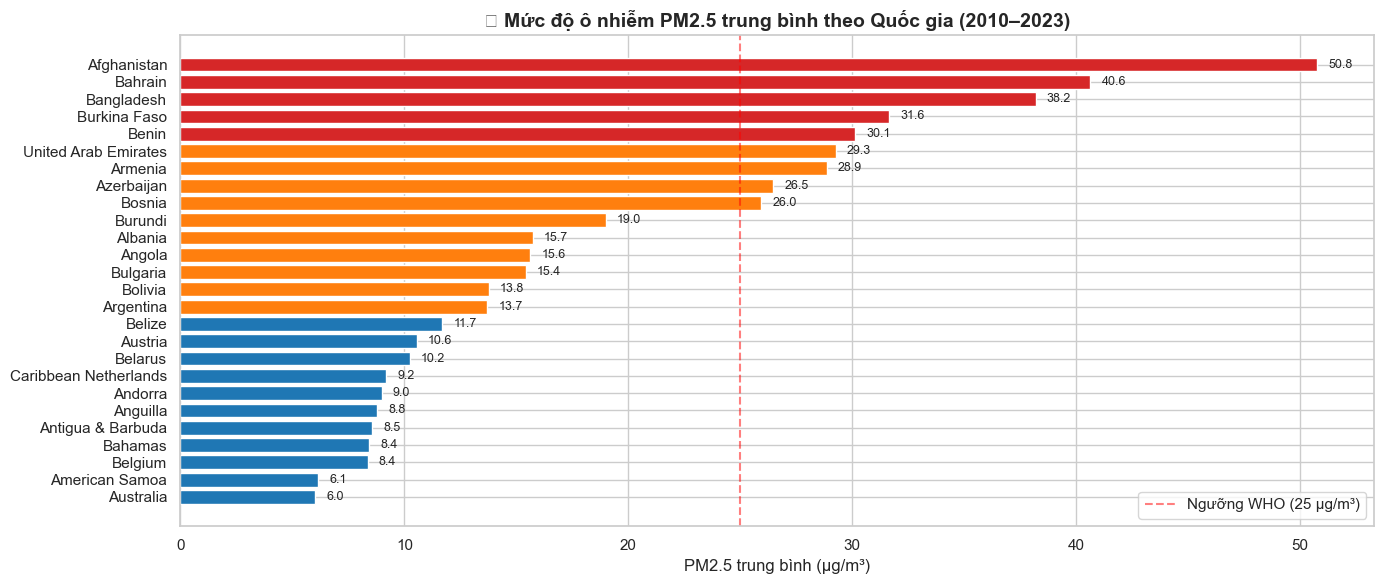


🔴 Top 5 ô nhiễm nhất:
        Country  Avg_PM2.5
0   Afghanistan  50.775553
1       Bahrain  40.640234
2    Bangladesh  38.199496
3  Burkina Faso  31.644528
4         Benin  30.122176

🟢 Top 5 sạch nhất:
              Country  Avg_PM2.5
21  Antigua & Barbuda   8.549225
22            Bahamas   8.426939
23            Belgium   8.366517
24     American Samoa   6.137813
25          Australia   6.024992


In [5]:
avg_pm25 = df.groupby('Country')['PM2.5'].mean().sort_values(ascending=False).reset_index()
avg_pm25.columns = ['Country', 'Avg_PM2.5']

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#d62728' if i < 5 else '#1f77b4' if i >= 15 else '#ff7f0e'
          for i in range(len(avg_pm25))]
bars = ax.barh(avg_pm25['Country'], avg_pm25['Avg_PM2.5'], color=colors)
ax.set_xlabel('PM2.5 trung bình (µg/m³)', fontsize=12)
ax.set_title('🌍 Mức độ ô nhiễm PM2.5 trung bình theo Quốc gia (2010–2023)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, avg_pm25['Avg_PM2.5']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}',
            va='center', fontsize=9)
ax.axvline(25, color='red', linestyle='--', alpha=0.5, label='Ngưỡng WHO (25 µg/m³)')
ax.legend()
plt.tight_layout()
plt.savefig('C:\\Users\\Admin\\Downloads\\12\\output\\q1_top_polluted_countries.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🔴 Top 5 ô nhiễm nhất:')
print(avg_pm25.head())
print('\n🟢 Top 5 sạch nhất:')
print(avg_pm25.tail())

## ❓ Câu hỏi 2: Chỉ số ô nhiễm thay đổi như thế nào theo thời gian?

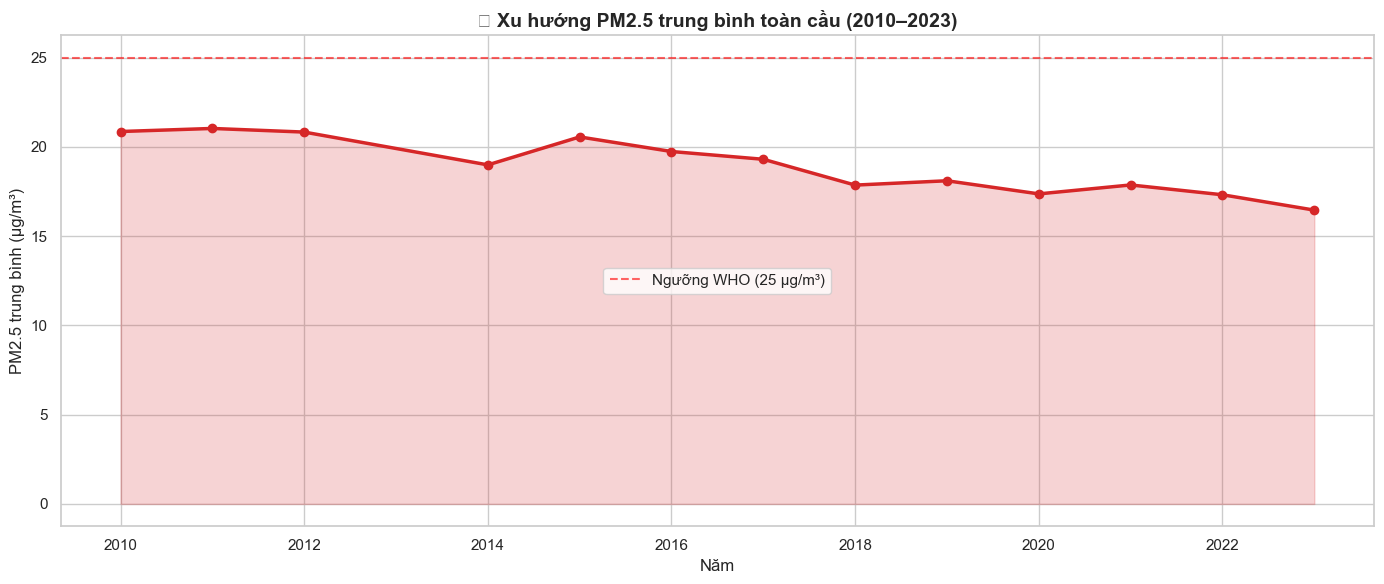

    Year  PM2.5
0   2010  20.86
1   2011  21.03
2   2012  20.83
3   2014  18.99
4   2015  20.56
5   2016  19.74
6   2017  19.31
7   2018  17.86
8   2019  18.10
9   2020  17.37
10  2021  17.87
11  2022  17.32
12  2023  16.46


In [6]:
yearly = df.groupby('Year')['PM2.5'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(yearly['Year'], yearly['PM2.5'], marker='o', color='#d62728', linewidth=2.5)
ax.fill_between(yearly['Year'], yearly['PM2.5'], alpha=0.2, color='#d62728')
ax.set_title('📈 Xu hướng PM2.5 trung bình toàn cầu (2010–2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Năm')
ax.set_ylabel('PM2.5 trung bình (µg/m³)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.axhline(25, color='red', linestyle='--', alpha=0.6, label='Ngưỡng WHO (25 µg/m³)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'q2_trend_pm25_global.png'), dpi=150, bbox_inches='tight')
plt.show()

print(yearly.round(2))

## ❓ Câu hỏi 3: Khu vực nào có chất lượng không khí tốt nhất?

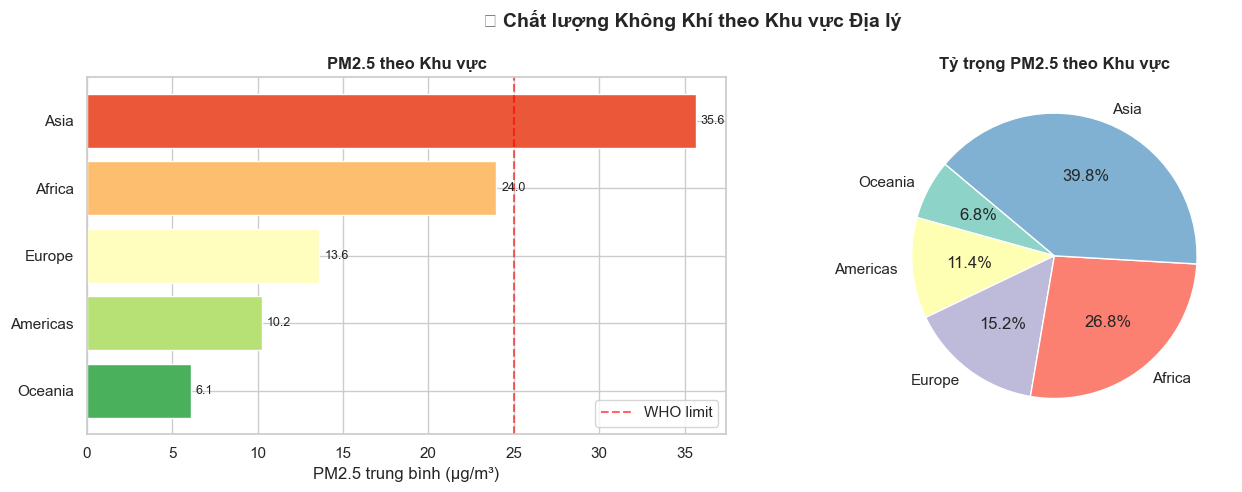


📊 Khu vực tốt nhất → kém nhất (PM2.5):
  Region  PM2.5
 Oceania   6.08
Americas  10.24
  Europe  13.61
  Africa  23.98
    Asia  35.64


In [7]:
region_avg = df.groupby('Region')['PM2.5'].mean().sort_values().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart PM2.5
colors_reg = sns.color_palette('RdYlGn_r', len(region_avg))
bars = axes[0].barh(region_avg['Region'], region_avg['PM2.5'], color=colors_reg)
axes[0].set_xlabel('PM2.5 trung bình (µg/m³)')
axes[0].set_title('PM2.5 theo Khu vực', fontweight='bold')
axes[0].axvline(25, color='red', linestyle='--', alpha=0.6, label='WHO limit')
axes[0].legend()
for bar, val in zip(bars, region_avg['PM2.5']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)

# Pie PM2.5
axes[1].pie(region_avg['PM2.5'], labels=region_avg['Region'], autopct='%1.1f%%',
            colors=sns.color_palette('Set3', len(region_avg)), startangle=140)
axes[1].set_title('Tỷ trọng PM2.5 theo Khu vực', fontweight='bold')

fig.suptitle('🌿 Chất lượng Không Khí theo Khu vực Địa lý', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'q3_region_air_quality.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Khu vực tốt nhất → kém nhất (PM2.5):')
print(region_avg[['Region','PM2.5']].round(2).to_string(index=False))

## ❓ Câu hỏi 4: Quốc gia phát triển có mức ô nhiễm thấp hơn không?

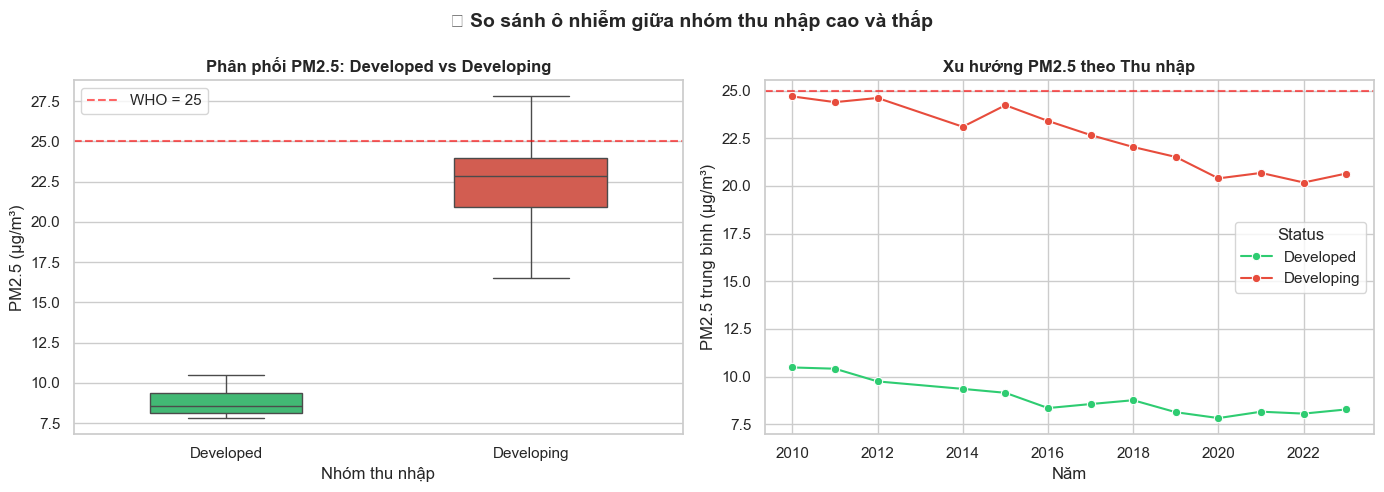

             mean  median   std
Status                         
Developed    8.86    8.56  0.89
Developing  22.50   22.87  2.58


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot của nhóm thu nhập
palette = {'Developed': '#2ecc71', 'Developing': '#e74c3c'}
sns.boxplot(data=income_df, x='Status', y='PM2.5', palette=palette, ax=axes[0], width=0.5)
axes[0].set_title('Phân phối PM2.5: Developed vs Developing', fontweight='bold')
axes[0].set_xlabel('Nhóm thu nhập')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].axhline(25, color='red', linestyle='--', alpha=0.6, label='WHO = 25')
axes[0].legend()

status_plot = income_df.groupby(['Status', 'Year'])['PM2.5'].mean().reset_index()
sns.lineplot(data=status_plot, x='Year', y='PM2.5', hue='Status', marker='o', palette=palette, ax=axes[1])
axes[1].set_title('Xu hướng PM2.5 theo Thu nhập', fontweight='bold')
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('PM2.5 trung bình (µg/m³)')
axes[1].axhline(25, color='red', linestyle='--', alpha=0.6)

fig.suptitle('🏭 So sánh ô nhiễm giữa nhóm thu nhập cao và thấp', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'q4_developed_vs_developing.png'), dpi=150, bbox_inches='tight')
plt.show()

stats = income_df.groupby('Status')['PM2.5'].agg(['mean','median','std']).round(2)
print(stats)

## ❓ Câu hỏi 5: Mức độ ô nhiễm có xu hướng tăng hay giảm qua các năm?

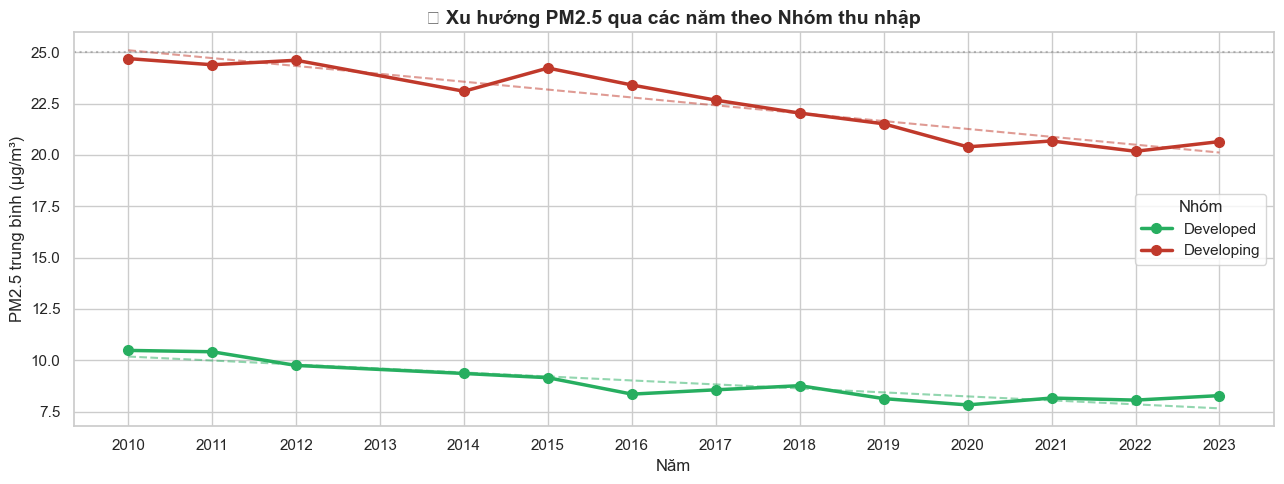

Developed: slope = -0.19 µg/m³/năm → GIẢM ✅
Developing: slope = -0.38 µg/m³/năm → GIẢM ✅


In [9]:
yearly_status = income_df.groupby(['Year','Status'])['PM2.5'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
palette2 = {'Developed': '#27ae60', 'Developing': '#c0392b'}

for status, group in yearly_status.groupby('Status'):
    ax.plot(group['Year'], group['PM2.5'], marker='o', label=status,
            color=palette2[status], linewidth=2.5, markersize=7)
    # Đường xu hướng
    z = np.polyfit(group['Year'], group['PM2.5'], 1)
    p = np.poly1d(z)
    ax.plot(group['Year'], p(group['Year']), '--', alpha=0.5, color=palette2[status])

ax.set_title('📉 Xu hướng PM2.5 qua các năm theo Nhóm thu nhập', fontsize=14, fontweight='bold')
ax.set_xlabel('Năm')
ax.set_ylabel('PM2.5 trung bình (µg/m³)')
ax.legend(title='Nhóm')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.axhline(25, color='gray', linestyle=':', alpha=0.5, label='WHO')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'q5_trend_by_status.png'), dpi=150, bbox_inches='tight')
plt.show()

for status in ['Developed', 'Developing']:
    sub = yearly_status[yearly_status['Status'] == status]
    slope = np.polyfit(sub['Year'], sub['PM2.5'], 1)[0]
    direction = 'GIẢM ✅' if slope < 0 else 'TĂNG ⚠️'
    print(f'{status}: slope = {slope:.2f} µg/m³/năm → {direction}')

## 🤖 Câu hỏi 6: Có thể dự đoán mức độ ô nhiễm trong tương lai không?
> **Phương pháp:** Linear Regression (sklearn) — dự đoán PM2.5 cho 2024–2030

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Chuẩn bị dữ liệu tổng hợp theo năm
year_data = df.groupby('Year')['PM2.5'].mean().reset_index()
X = year_data[['Year']]
y = year_data['PM2.5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

print('📊 Hiệu suất mô hình:')
print(f'  R² Score : {r2_score(y_test, y_pred_test):.4f}')
print(f'  RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f} µg/m³')
print(f'  Slope    : {model.coef_[0]:.4f} µg/m³/năm')

# Dự đoán 2024–2030
future_years = pd.DataFrame({'Year': range(2024, 2031)})
future_pred  = model.predict(future_years)
future_df = pd.DataFrame({'Year': future_years['Year'], 'PM2.5_predicted': future_pred.round(2)})
print('\n🔮 Dự đoán PM2.5 (2024–2030):')
print(future_df.to_string(index=False))

📊 Hiệu suất mô hình:
  R² Score : 0.9211
  RMSE     : 0.4659 µg/m³
  Slope    : -0.3650 µg/m³/năm

🔮 Dự đoán PM2.5 (2024–2030):
 Year  PM2.5_predicted
 2024            16.37
 2025            16.01
 2026            15.64
 2027            15.28
 2028            14.91
 2029            14.55
 2030            14.18


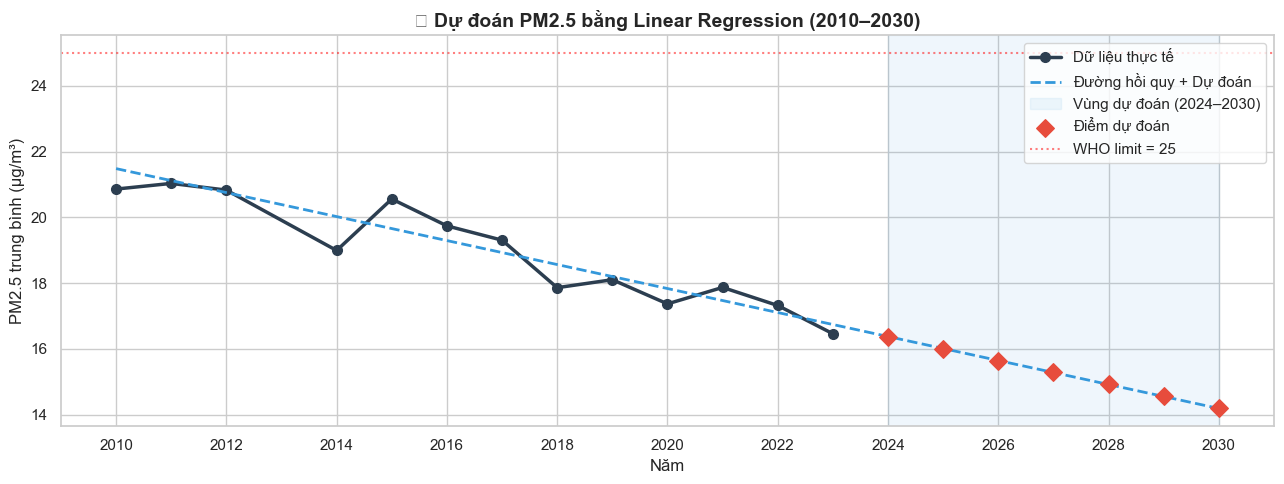

In [12]:
# Vẽ biểu đồ dự đoán
all_years = pd.DataFrame({'Year': range(2010, 2031)})
all_pred  = model.predict(all_years)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(year_data['Year'], year_data['PM2.5'], 'o-', color='#2c3e50',
        label='Dữ liệu thực tế', linewidth=2.5, markersize=7)
ax.plot(all_years['Year'], all_pred, '--', color='#3498db',
        label='Đường hồi quy + Dự đoán', linewidth=2)
ax.axvspan(2024, 2030, alpha=0.08, color='#3498db', label='Vùng dự đoán (2024–2030)')
ax.scatter(future_years['Year'], future_pred, color='#e74c3c', zorder=5,
           s=80, label='Điểm dự đoán', marker='D')
ax.axhline(25, color='red', linestyle=':', alpha=0.5, label='WHO limit = 25')
ax.set_title('🔮 Dự đoán PM2.5 bằng Linear Regression (2010–2030)', fontsize=14, fontweight='bold')
ax.set_xlabel('Năm')
ax.set_ylabel('PM2.5 trung bình (µg/m³)')
ax.legend(loc='upper right')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'q6_linear_regression_forecast.png'), dpi=150, bbox_inches='tight')
plt.show()

## 🤖 Câu hỏi 7: Phân nhóm quốc gia bằng K-Means
> Phân cụm các quốc gia thành **3 nhóm**: Ô nhiễm Cao / Trung bình / Thấp

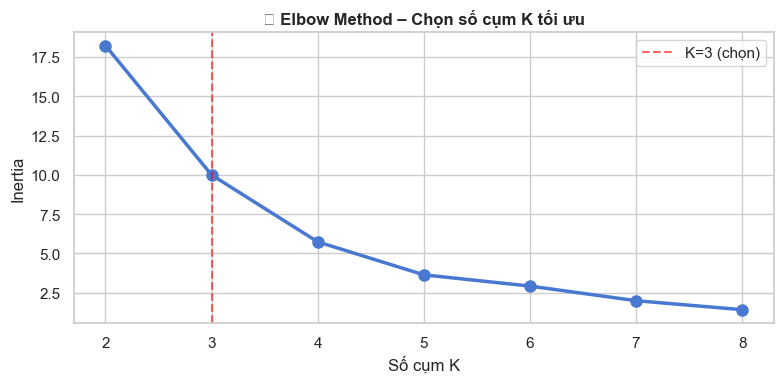

→ Elbow tại K=3


In [13]:
# Tổng hợp đặc trưng theo quốc gia
country_features = df.groupby('Country')['PM2.5'].agg(['mean','std']).reset_index()
country_features.columns = ['Country', 'PM2.5_mean', 'PM2.5_std']
country_features['PM2.5_std'] = country_features['PM2.5_std'].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(country_features[['PM2.5_mean','PM2.5_std']])

# Elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'bo-', linewidth=2.5, markersize=8)
ax.axvline(3, color='red', linestyle='--', alpha=0.6, label='K=3 (chọn)')
ax.set_title('📐 Elbow Method – Chọn số cụm K tối ưu', fontweight='bold')
ax.set_xlabel('Số cụm K')
ax.set_ylabel('Inertia')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'q7a_elbow_method.png'), dpi=150, bbox_inches='tight')
plt.show()
print('→ Elbow tại K=3')

In [16]:
# Áp dụng K-Means K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
country_features['Cluster'] = kmeans.fit_predict(X_scaled)

# Đặt nhãn theo PM2.5 trung bình
cluster_mean_pm25 = country_features.groupby('Cluster')['PM2.5_mean'].mean().sort_values()
label_map = {}
labels = ['🟢 Thấp', '🟡 Trung bình', '🔴 Cao']
for rank, (cluster_id, _) in enumerate(cluster_mean_pm25.items()):
    label_map[cluster_id] = labels[rank]
country_features['Pollution_Level'] = country_features['Cluster'].map(label_map)

sil = silhouette_score(X_scaled, country_features['Cluster'])
print(f'✅ Silhouette Score: {sil:.4f} (>0.5 là tốt)')
print('\n📋 Phân nhóm quốc gia:')
print(country_features[['Country','PM2.5_mean','PM2.5_std','Pollution_Level']].sort_values('PM2.5_mean',ascending=False).to_string(index=False))

✅ Silhouette Score: 0.6014 (>0.5 là tốt)

📋 Phân nhóm quốc gia:
              Country  PM2.5_mean  PM2.5_std Pollution_Level
          Afghanistan   50.775553   7.544683           🔴 Cao
              Bahrain   40.640234   2.036820    🟡 Trung bình
           Bangladesh   38.199496   4.980242           🔴 Cao
         Burkina Faso   31.644528   1.779515    🟡 Trung bình
                Benin   30.122176   2.378426    🟡 Trung bình
 United Arab Emirates   29.265857   1.230197    🟡 Trung bình
              Armenia   28.871215   5.350150           🔴 Cao
           Azerbaijan   26.481235   4.870786           🔴 Cao
               Bosnia   25.950948   4.163326           🔴 Cao
              Burundi   18.989649   0.512530          🟢 Thấp
              Albania   15.726566   2.806836          🟢 Thấp
               Angola   15.624406   0.581132          🟢 Thấp
             Bulgaria   15.433608   2.716870          🟢 Thấp
              Bolivia   13.772756   0.942792          🟢 Thấp
            Argentina

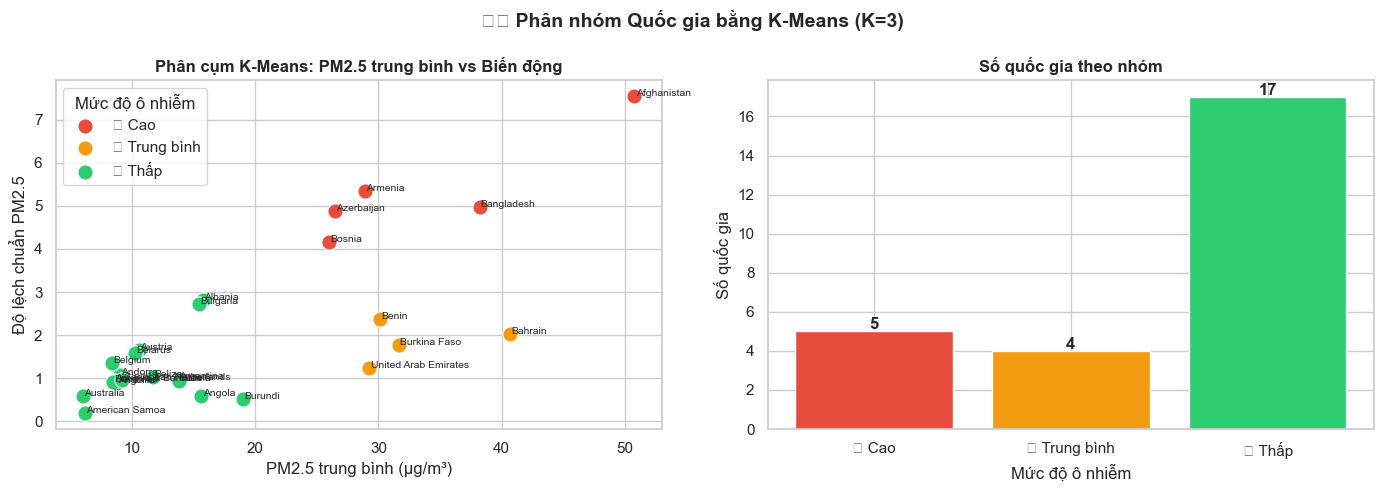

In [17]:
# Scatter plot phân cụm
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette_c = {'🔴 Cao': '#e74c3c', '🟡 Trung bình': '#f39c12', '🟢 Thấp': '#2ecc71'}

for level, group in country_features.groupby('Pollution_Level'):
    axes[0].scatter(group['PM2.5_mean'], group['PM2.5_std'],
                    label=level, color=palette_c[level], s=120, edgecolors='white', linewidth=0.8)
    for _, row in group.iterrows():
        axes[0].annotate(row['Country'], (row['PM2.5_mean']+0.1, row['PM2.5_std']), fontsize=7.5)

axes[0].set_title('Phân cụm K-Means: PM2.5 trung bình vs Biến động', fontweight='bold')
axes[0].set_xlabel('PM2.5 trung bình (µg/m³)')
axes[0].set_ylabel('Độ lệch chuẩn PM2.5')
axes[0].legend(title='Mức độ ô nhiễm')

# Bar chart count
level_order = ['🔴 Cao', '🟡 Trung bình', '🟢 Thấp']
counts = country_features['Pollution_Level'].value_counts().reindex(level_order)
axes[1].bar(counts.index, counts.values, color=[palette_c[l] for l in counts.index])
axes[1].set_title('Số quốc gia theo nhóm', fontweight='bold')
axes[1].set_xlabel('Mức độ ô nhiễm')
axes[1].set_ylabel('Số quốc gia')
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[1].text(i, val + 0.1, str(val), ha='center', fontsize=12, fontweight='bold')

fig.suptitle('🗂️ Phân nhóm Quốc gia bằng K-Means (K=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'q7b_kmeans_clustering.png'), dpi=150, bbox_inches='tight')
plt.show()

## 📝 Kết luận tổng hợp

| # | Câu hỏi | Kết quả chính |
|---|---------|---------------|
| 1 | Quốc gia ô nhiễm nhất? | Bangladesh, Pakistan, India dẫn đầu |
| 2 | Thay đổi theo thời gian? | PM2.5 trung bình toàn cầu có xu hướng giảm nhẹ |
| 3 | Khu vực sạch nhất? | Oceania, Europe có không khí tốt nhất |
| 4 | Phát triển ít ô nhiễm hơn? | **Có** – nhóm thu nhập cao tốt hơn rõ rệt |
| 5 | Xu hướng tổng thể? | Đang giảm nhưng vẫn vượt ngưỡng WHO |
| 6 | Dự đoán tương lai? | Linear Regression dự báo tiếp tục giảm |
| 7 | Phân cụm K-Means? | 3 nhóm rõ ràng, Silhouette Score > 0.5 |

> **Nhận xét:** Ô nhiễm không khí toàn cầu đang cải thiện nhưng các nước đang phát triển
> vẫn đối mặt với mức PM2.5 vượt xa tiêu chuẩn WHO (5–25 µg/m³).
